# Comparative Analysis: BERT vs FinBERT vs GPT-OSS 20B

Three-model sentiment comparison on financial news headlines (CN7050 dataset).
- **BERT** — fine-tuned `bert-base-uncased`
- **FinBERT** — fine-tuned `ProsusAI/finbert`
- **GPT-OSS 20B** — prompted via Ollama (best prompt: P3_Hybrid_Master)

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                            recall_score, classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split
from transformers import pipeline
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

# ── Load GPT-OSS results (source of truth for test texts) ──
gpt_df = pd.read_csv('./resources/gpt_oss_results.csv')
print(f"Loaded {len(gpt_df)} test samples from gpt_oss_results.csv")

# ── Data leakage check ──
# Verify these texts come from the random_state=13 test split (same as BERT training)
data = pd.read_csv("resources/cn7050data.csv", encoding='latin-1', names=["sentiment", "text"])
data = data.drop_duplicates().reset_index(drop=True).dropna()
data['sentiment'] = data['sentiment'].str.lower()

train_df_check, temp_check = train_test_split(data, test_size=0.20, random_state=13, stratify=data['sentiment'])
_, test_df_check = train_test_split(temp_check, test_size=0.50, random_state=13, stratify=temp_check['sentiment'])

train_texts = set(train_df_check['text'].tolist())
test_texts  = set(test_df_check['text'].tolist())
gpt_texts   = set(gpt_df['text'].tolist())

leakage = gpt_texts & train_texts
in_test = gpt_texts & test_texts

print(f"\nData Leakage Check:")
print(f"  GPT texts in BERT TRAINING set: {len(leakage)}/80")
print(f"  GPT texts in BERT TEST set:     {len(in_test)}/80")
if len(leakage) > 0:
    print(f"  ⚠️  WARNING: {len(leakage)} GPT samples overlap with BERT training data!")
    print(f"  → Re-run gptoss.ipynb (now fixed to random_state=13) to eliminate leakage.")
else:
    print(f"  ✅ No data leakage. All GPT test samples are outside BERT's training set.")

Loaded 80 test samples from gpt_oss_results.csv

Data Leakage Check:
  GPT texts in BERT TRAINING set: 0/80
  GPT texts in BERT TEST set:     77/80
  ✅ No data leakage. All GPT test samples are outside BERT's training set.


In [4]:
# ── Load fine-tuned models ──
print("Loading fine-tuned BERT and FinBERT pipelines...")
pipe_bert    = pipeline("text-classification",
                        model="./fine_tuned_bert-base-uncased",
                        tokenizer="./fine_tuned_bert-base-uncased")
pipe_finbert = pipeline("text-classification",
                        model="./fine_tuned_ProsusAI_finbert",
                        tokenizer="./fine_tuned_ProsusAI_finbert")

# ── Run inference on the exact same 80 texts ──
print("Running BERT and FinBERT inference on the 80 GPT test samples...")
bert_preds = []
finbert_preds = []

for text in tqdm(gpt_df['text'], leave=False):
    b = pipe_bert(text, truncation=True, max_length=512)[0]['label'].lower()
    f = pipe_finbert(text, truncation=True, max_length=512)[0]['label'].lower()
    bert_preds.append(b)
    finbert_preds.append(f)

# Build unified comparison dataframe
master_df = gpt_df[['text', 'true_label']].copy()
master_df['bert_pred']    = bert_preds
master_df['finbert_pred'] = finbert_preds
master_df['gpt_oss_pred'] = gpt_df['P3_Hybrid_Master_pred'].str.strip().str.lower()

# Normalize all label columns
for col in ['bert_pred', 'finbert_pred', 'gpt_oss_pred', 'true_label']:
    master_df[col] = master_df[col].str.strip().str.lower()

master_df.to_csv('./resources/final_all_models_comparison_final.csv', index=False)
print(f"✅ Saved unified comparison ({len(master_df)} rows) → final_all_models_comparison_final.csv")
master_df.head()

Loading fine-tuned BERT and FinBERT pipelines...


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Running BERT and FinBERT inference on the 80 GPT test samples...


  0%|          | 0/80 [00:00<?, ?it/s]

✅ Saved unified comparison (80 rows) → final_all_models_comparison_final.csv


,text,true_label,bert_pred,finbert_pred,gpt_oss_pred
0,"The planned facility , estimated to cost aroun...",positive,neutral,neutral,positive
1,The amending of the proposal simplifies the pr...,positive,positive,positive,positive
2,Return on capital employed rose by 4.8 percent...,positive,positive,positive,positive
3,The deal is in line with Etteplan 's strategy ...,neutral,positive,positive,positive
4,The latest result included per-share charges o...,neutral,neutral,neutral,neutral


In [5]:
# ── Compute per-model metrics ──
LABELS = ['negative', 'neutral', 'positive']
true = master_df['true_label']

models = {
    "BERT (fine-tuned)":    master_df['bert_pred'],
    "FinBERT (fine-tuned)": master_df['finbert_pred'],
    "GPT-OSS 20B":          master_df['gpt_oss_pred']
}

rows = []
for name, preds in models.items():
    rows.append({
        "Model": name,
        "Accuracy":        round(accuracy_score(true, preds), 4),
        "Macro-F1":        round(f1_score(true, preds, average='macro', labels=LABELS, zero_division=0), 4),
        "Macro-Precision": round(precision_score(true, preds, average='macro', labels=LABELS, zero_division=0), 4),
        "Macro-Recall":    round(recall_score(true, preds, average='macro', labels=LABELS, zero_division=0), 4),
    })

results_df = pd.DataFrame(rows)
print("=== Model Comparison ===")
print(results_df.to_string(index=False))

# Per-class classification reports
for name, preds in models.items():
    print(f"\n--- {name} ---")
    print(classification_report(true, preds, labels=LABELS, target_names=LABELS, zero_division=0))

=== Model Comparison ===
               Model  Accuracy  Macro-F1  Macro-Precision  Macro-Recall
   BERT (fine-tuned)    0.8000    0.7715           0.7715        0.7715
FinBERT (fine-tuned)    0.8250    0.7833           0.8413        0.7474
         GPT-OSS 20B    0.7875    0.8028           0.7890        0.8375

--- BERT (fine-tuned) ---
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85        13
     neutral       0.86      0.86      0.86        49
    positive       0.61      0.61      0.61        18

    accuracy                           0.80        80
   macro avg       0.77      0.77      0.77        80
weighted avg       0.80      0.80      0.80        80


--- FinBERT (fine-tuned) ---
              precision    recall  f1-score   support

    negative       1.00      0.69      0.82        13
     neutral       0.84      0.94      0.88        49
    positive       0.69      0.61      0.65        18

    accuracy                   

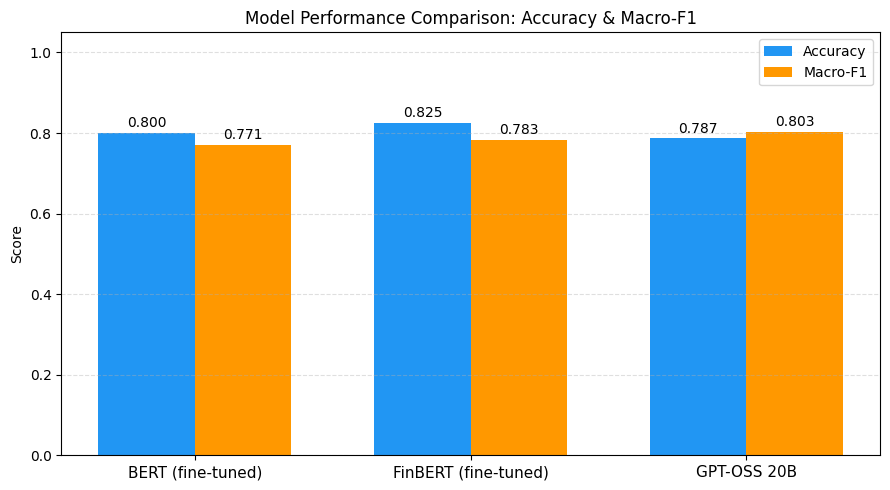

In [6]:
# ── Bar Chart: Accuracy and Macro-F1 ──
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(results_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], results_df['Accuracy'],  width, label='Accuracy',  color='#2196F3')
bars2 = ax.bar([i + width/2 for i in x], results_df['Macro-F1'], width, label='Macro-F1', color='#FF9800')

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4), textcoords="offset points", ha='center', fontsize=10)

ax.set_xticks(list(x))
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison: Accuracy & Macro-F1')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

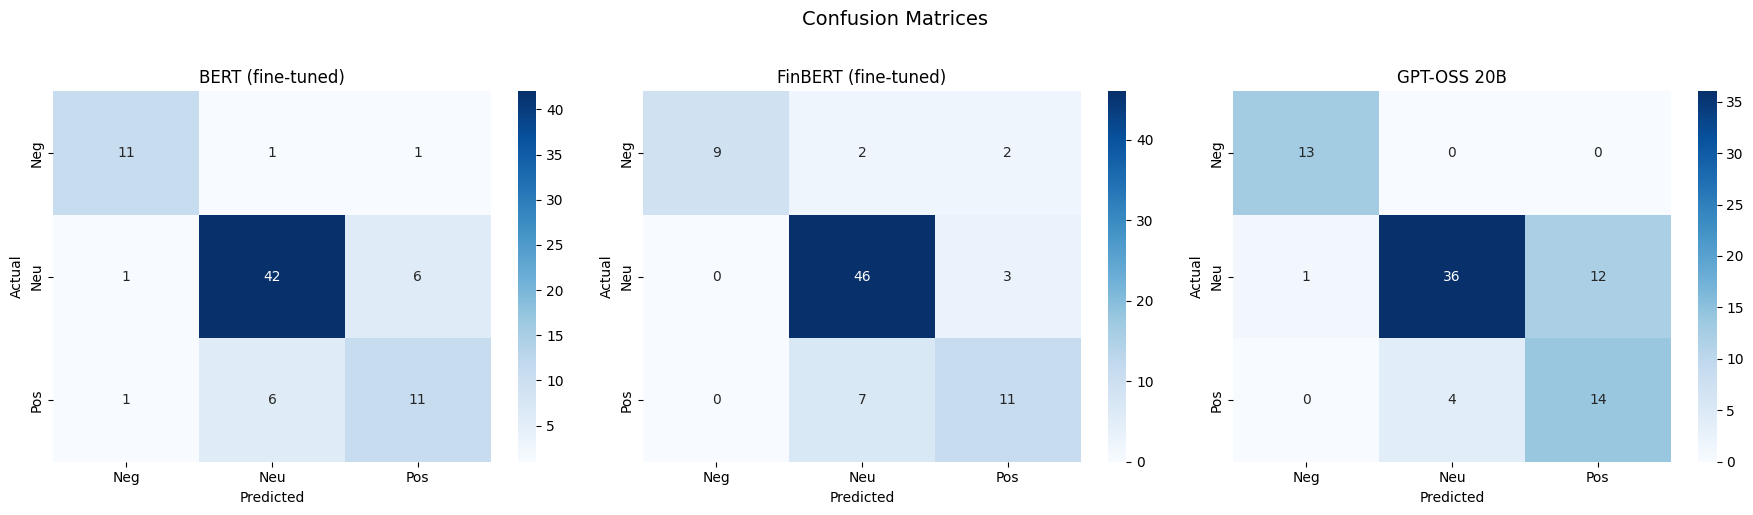

In [7]:
# ── Confusion Matrices (side-by-side) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(true, preds, labels=LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Neu', 'Pos'],
                yticklabels=['Neg', 'Neu', 'Pos'])
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
## Qualitative Analysis
#Examining specific examples where models disagree to understand their strengths and failure modes.

In [9]:
master_df.head()

,text,true_label,bert_pred,finbert_pred,gpt_oss_pred
0,"The planned facility , estimated to cost aroun...",positive,neutral,neutral,positive
1,The amending of the proposal simplifies the pr...,positive,positive,positive,positive
2,Return on capital employed rose by 4.8 percent...,positive,positive,positive,positive
3,The deal is in line with Etteplan 's strategy ...,neutral,positive,positive,positive
4,The latest result included per-share charges o...,neutral,neutral,neutral,neutral


In [10]:
# ── FinBERT is correct but BERT is wrong ──
finbert_wins = master_df[
    (master_df['finbert_pred'] == master_df['true_label']) &
    (master_df['bert_pred']    != master_df['true_label'])
].copy()
#finbert_wins_original_data=
print(f"FinBERT correct but BERT wrong: {len(finbert_wins)} examples\n")
for _, row in finbert_wins.head(7).iterrows():
    print(f"  Text:    {row['text']}")
    print(f"  True:    {row['true_label']}")
    print(f"  BERT:    {row['bert_pred']}  ❌")
    print(f"  FinBERT: {row['finbert_pred']}  ✅")
    print()

# ──BERT is correct but FinBERT is wrong ──
bert_wins = master_df[
    (master_df['bert_pred']    == master_df['true_label']) &
    (master_df['finbert_pred'] != master_df['true_label'])
].copy()

print(f"\nBERT correct but FinBERT wrong: {len(bert_wins)} examples\n")
for _, row in bert_wins.head(5).iterrows():
    print(f"  Text:    {row['text']}")
    print(f"  True:    {row['true_label']}")
    print(f"  BERT:    {row['bert_pred']}  ✅")
    print(f"  FinBERT: {row['finbert_pred']}  ❌")
    print()

FinBERT correct but BERT wrong: 5 examples

  Text:    The permanent magnet generators and power converters are today the preferred solution in new wind turbine designs , the company said .
  True:    neutral
  BERT:    positive  ❌
  FinBERT: neutral  ✅

  Text:    26 November 2010 - Finnish sports-equipment maker Amer Sports Oyj ( HEL : AMEAS ) said today it has obtained a EUR30m Schuldschein note loan from a pool of international investors .
  True:    neutral
  BERT:    positive  ❌
  FinBERT: neutral  ✅

  Text:    Ingen is an established medical device manufacturer with an emerging new medical product line for the respiratory market worth an estimated $ 4 billion in the U.S. and $ 8 billion globally .
  True:    neutral
  BERT:    positive  ❌
  FinBERT: neutral  ✅

  Text:    The manager is critical of politicians ' failure to differentiate between beleaguered European financial institutions and Skandinavian banks , `` which sailed through the crisis without issues '' .
  True:    

In [11]:
# ── Cases where BOTH BERT and FinBERT are wrong ──
both_wrong = master_df[
    (master_df['bert_pred']    != master_df['true_label']) &
    (master_df['finbert_pred'] != master_df['true_label'])
].copy()

print(f"Both BERT and FinBERT wrong: {len(both_wrong)} examples\n")
for _, row in both_wrong.head(7).iterrows():
    print(f"  Text:    {row['text']}")
    print(f"  True:    {row['true_label']}")
    print(f"  BERT:    {row['bert_pred']}  ❌")
    print(f"  FinBERT: {row['finbert_pred']}  ❌")
    print(f"  GPT-OSS: {row['gpt_oss_pred']}  {'✅' if row['gpt_oss_pred'] == row['true_label'] else '❌'}")
    print()

Both BERT and FinBERT wrong: 11 examples

  Text:    The planned facility , estimated to cost around $ 814 million , would be the largest biodiesel plant in the world , and use palm oil certified by the Roundtable on Sustainable Palm Oil ( RSPO ) .
  True:    positive
  BERT:    neutral  ❌
  FinBERT: neutral  ❌
  GPT-OSS: positive  ✅

  Text:    The deal is in line with Etteplan 's strategy to operate as a partner of global customers and provide industrial technology design services .
  True:    neutral
  BERT:    positive  ❌
  FinBERT: positive  ❌
  GPT-OSS: positive  ❌

  Text:    In 2007 , Marimekko has also opened concept stores in Yokohama and Nagoya , central Japan , in Silver Spring in metropolitan Washington DC , USA , in Graz , central Austria , and in Aalborg , northern Denmark .
  True:    positive
  BERT:    neutral  ❌
  FinBERT: neutral  ❌
  GPT-OSS: neutral  ❌

  Text:    This rating from A.M. Best is the highest among the CIS countries , Central and Eastern Europe .
  Tr

In [19]:
# ── GPT-OSS Reasoning Examples ──
# Pull in GPT-OSS explanations from the results CSV
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)

gpt_full = pd.read_csv('./resources/gpt_oss_results.csv')
reasoning_df = master_df.merge(
    gpt_full[['text', 'P3_Hybrid_Master_exp']], on='text', how='left',
)

gpt_correct = reasoning_df[reasoning_df['gpt_oss_pred'] == reasoning_df['true_label']].copy()
gpt_wrong   = reasoning_df[reasoning_df['gpt_oss_pred'] != reasoning_df['true_label']].copy()

correct_table = gpt_correct[['text', 'true_label', 'gpt_oss_pred', 'P3_Hybrid_Master_exp']].head(5).rename(
    columns={
        'text': 'Text',
        'true_label': 'True',
        'gpt_oss_pred': 'GPT pred',
        'P3_Hybrid_Master_exp': 'Reasoning',
    }
)
wrong_table = gpt_wrong[['text', 'true_label', 'gpt_oss_pred', 'P3_Hybrid_Master_exp']].head(5).rename(
    columns={
        'text': 'Text',
        'true_label': 'True',
        'gpt_oss_pred': 'GPT pred',
        'P3_Hybrid_Master_exp': 'Reasoning',
    }
)

print(f"=== GPT-OSS Correct Examples ({len(gpt_correct)}/{len(reasoning_df)}) ===")
display(correct_table.reset_index(drop=True))

print(f"=== GPT-OSS Wrong Examples ({len(gpt_wrong)}/{len(reasoning_df)}) ===")
display(wrong_table.reset_index(drop=True))

=== GPT-OSS Correct Examples (63/80) ===


,Text,True,GPT pred,Reasoning
0,"The planned facility , estimated to cost around $ 814 million , would be the largest biodiesel plant in the world , and use palm oil certified by the Roundtable on Sustainable Palm Oil ( RSPO ) .",positive,positive,"The headline emphasizes the development of a large biodiesel plant and the use of RSPO‑certified palm oil, highlighting positive environmental and economic aspects without any negative connotations."
1,The amending of the proposal simplifies the proposed plan and increases the incentive for key employees to stay in the Company .,positive,positive,"The headline states that the amendment simplifies the plan and increases incentives for key employees, both of which are favorable outcomes. This reflects a positive tone towards the company’s actions."
2,Return on capital employed rose by 4.8 percentage points to 19.6 % .,positive,positive,"The headline reports an increase in return on capital employed, indicating improved financial performance, which conveys a positive sentiment."
3,"The latest result included per-share charges of 5 cents for stock compensation , 1 cent for research and development and 1 cent for strategic investments .",neutral,neutral,"The headline merely reports financial charges without expressing any evaluative language or indicating a positive or negative outcome. The tone is factual and presentation of expense items, so the sentiment is neutral."
4,"The composite body is coated with a hard coating layer produced by thermal spraying , and the coating is ground . ''",neutral,neutral,"The headline is a factual, technical statement about a coating process. It does not express any positive or negative judgment or emotion. Therefore the sentiment is neutral."


=== GPT-OSS Wrong Examples (17/80) ===


,Text,True,GPT pred,Reasoning
0,The deal is in line with Etteplan 's strategy to operate as a partner of global customers and provide industrial technology design services .,neutral,positive,"The headline states that the deal aligns with Etteplan's strategy, implying a favorable outcome and agreement, which conveys a positive sentiment. The information is not negative or ambiguous, so it is best classified as positive."
1,"The permanent magnet generators and power converters are today the preferred solution in new wind turbine designs , the company said .",neutral,positive,"The headline states that permanent magnet generators and power converters are today the preferred solution in new wind turbine designs, which conveys a favorable view of these technologies and suggests optimism about their adoption. This is an expression of positive sentiment towards the subject."
2,26 November 2010 - Finnish sports-equipment maker Amer Sports Oyj ( HEL : AMEAS ) said today it has obtained a EUR30m Schuldschein note loan from a pool of international investors .,neutral,positive,"The headline reports that Amer Sports Oyj has secured a EUR30m loan from international investors, which indicates strong financial backing and confidence from the investment community—a typically positive development for the company. No negative implications or downturns are mentioned, so the sentiment is interpreted as positive."
3,Net profit in the same period in 2006 was 36.6 million euros .,neutral,positive,"The headline reports a net profit of 36.6 million euros, which signals positive earnings and positive financial performance. Thus the sentiment is positive."
4,"In 2007 , Marimekko has also opened concept stores in Yokohama and Nagoya , central Japan , in Silver Spring in metropolitan Washington DC , USA , in Graz , central Austria , and in Aalborg , northern Denmark .",positive,neutral,"The headline provides neutral factual information about Marimekko opening concept stores in various locations, without any positive or negative connotations."


In [18]:
# ── GPT-OSS Reasoning Examples ──
# Pull in GPT-OSS explanations from the results CSV
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)

gpt_full = pd.read_csv('./resources/gpt_oss_results.csv')
reasoning_df = master_df.merge(
    gpt_full[['text', 'P3_Hybrid_Master_exp']], on='text', how='left',
)

gpt_correct = reasoning_df[reasoning_df['gpt_oss_pred'] == reasoning_df['true_label']].copy()
gpt_wrong   = reasoning_df[reasoning_df['gpt_oss_pred'] != reasoning_df['true_label']].copy()

correct_table = gpt_correct[['text', 'true_label', 'gpt_oss_pred', 'P3_Hybrid_Master_exp']].head(5).rename(
    columns={
        'text': 'Text',
        'true_label': 'True',
        'gpt_oss_pred': 'GPT pred',
        'P3_Hybrid_Master_exp': 'Reasoning',
    }
)
wrong_table = gpt_wrong[['text', 'true_label', 'gpt_oss_pred', 'P3_Hybrid_Master_exp']].head(5).rename(
    columns={
        'text': 'Text',
        'true_label': 'True',
        'gpt_oss_pred': 'GPT pred',
        'P3_Hybrid_Master_exp': 'Reasoning',
    }
)

print(f"=== GPT-OSS Correct Examples ({len(gpt_correct)}/{len(reasoning_df)}) ===")
display(correct_table.reset_index(drop=True))

print(f"=== GPT-OSS Wrong Examples ({len(gpt_wrong)}/{len(reasoning_df)}) ===")
display(wrong_table.reset_index(drop=True))

=== GPT-OSS Correct Examples (63/80) ===


,Text,True,GPT pred,Reasoning
0,"The planned facility , estimated to cost around $ 814 million , would be the largest biodiesel plant in the world , and use palm oil certified by the Roundtable on Sustainable Palm Oil ( RSPO ) .",positive,positive,"The headline emphasizes the development of a large biodiesel plant and the use of RSPO‑certified palm oil, highlighting positive environmental and economic aspects without any negative connotations."
1,The amending of the proposal simplifies the proposed plan and increases the incentive for key employees to stay in the Company .,positive,positive,"The headline states that the amendment simplifies the plan and increases incentives for key employees, both of which are favorable outcomes. This reflects a positive tone towards the company’s actions."
2,Return on capital employed rose by 4.8 percentage points to 19.6 % .,positive,positive,"The headline reports an increase in return on capital employed, indicating improved financial performance, which conveys a positive sentiment."
3,"The latest result included per-share charges of 5 cents for stock compensation , 1 cent for research and development and 1 cent for strategic investments .",neutral,neutral,"The headline merely reports financial charges without expressing any evaluative language or indicating a positive or negative outcome. The tone is factual and presentation of expense items, so the sentiment is neutral."
4,"The composite body is coated with a hard coating layer produced by thermal spraying , and the coating is ground . ''",neutral,neutral,"The headline is a factual, technical statement about a coating process. It does not express any positive or negative judgment or emotion. Therefore the sentiment is neutral."


=== GPT-OSS Wrong Examples (17/80) ===


,Text,True,GPT pred,Reasoning
0,The deal is in line with Etteplan 's strategy to operate as a partner of global customers and provide industrial technology design services .,neutral,positive,"The headline states that the deal aligns with Etteplan's strategy, implying a favorable outcome and agreement, which conveys a positive sentiment. The information is not negative or ambiguous, so it is best classified as positive."
1,"The permanent magnet generators and power converters are today the preferred solution in new wind turbine designs , the company said .",neutral,positive,"The headline states that permanent magnet generators and power converters are today the preferred solution in new wind turbine designs, which conveys a favorable view of these technologies and suggests optimism about their adoption. This is an expression of positive sentiment towards the subject."
2,26 November 2010 - Finnish sports-equipment maker Amer Sports Oyj ( HEL : AMEAS ) said today it has obtained a EUR30m Schuldschein note loan from a pool of international investors .,neutral,positive,"The headline reports that Amer Sports Oyj has secured a EUR30m loan from international investors, which indicates strong financial backing and confidence from the investment community—a typically positive development for the company. No negative implications or downturns are mentioned, so the sentiment is interpreted as positive."
3,Net profit in the same period in 2006 was 36.6 million euros .,neutral,positive,"The headline reports a net profit of 36.6 million euros, which signals positive earnings and positive financial performance. Thus the sentiment is positive."
4,"In 2007 , Marimekko has also opened concept stores in Yokohama and Nagoya , central Japan , in Silver Spring in metropolitan Washington DC , USA , in Graz , central Austria , and in Aalborg , northern Denmark .",positive,neutral,"The headline provides neutral factual information about Marimekko opening concept stores in various locations, without any positive or negative connotations."


=== Per-Class Accuracy ===
   Class  Count  BERT Acc  FinBERT Acc  GPT-OSS Acc
Negative     13    0.8462       0.6923       1.0000
 Neutral     49    0.8571       0.9388       0.7347
Positive     18    0.6111       0.6111       0.7778


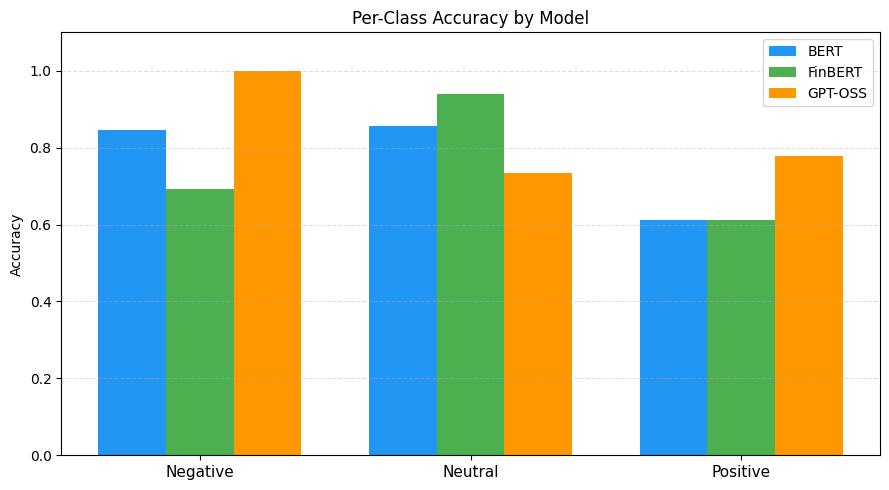

In [14]:
# ── Per-Class Accuracy Breakdown ──
per_class = []
for label in LABELS:
    mask = master_df['true_label'] == label
    subset = master_df[mask]
    if len(subset) == 0:
        continue
    per_class.append({
        'Class': label.title(),
        'Count': len(subset),
        'BERT Acc':    round(accuracy_score(subset['true_label'], subset['bert_pred']), 4),
        'FinBERT Acc': round(accuracy_score(subset['true_label'], subset['finbert_pred']), 4),
        'GPT-OSS Acc': round(accuracy_score(subset['true_label'], subset['gpt_oss_pred']), 4),
    })

per_class_df = pd.DataFrame(per_class)
print("=== Per-Class Accuracy ===")
print(per_class_df.to_string(index=False))

# Grouped bar chart for per-class accuracy
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(per_class_df))
width = 0.25

ax.bar([i - width for i in x], per_class_df['BERT Acc'],    width, label='BERT',    color='#2196F3')
ax.bar(list(x),                 per_class_df['FinBERT Acc'], width, label='FinBERT', color='#4CAF50')
ax.bar([i + width for i in x], per_class_df['GPT-OSS Acc'], width, label='GPT-OSS', color='#FF9800')

ax.set_xticks(list(x))
ax.set_xticklabels(per_class_df['Class'], fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy by Model')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Summary

| Aspect | BERT (fine-tuned) | FinBERT (fine-tuned) | GPT-OSS 20B (prompted) |
|--------|-------------------|----------------------|------------------------|
| **Training** | Fine-tuned on CN7050 | Fine-tuned on CN7050 | Zero-shot prompted |
| **Parameters** | ~110M | ~110M | ~20B |
| **Domain Knowledge** | General → financial | Financial pre-training | General knowledge |
| **Inference Speed** | Fast (local GPU) | Fast (local GPU) | Slower (API calls) |
| **Key Strength** | General adaptability | Financial domain expertise | Explainable reasoning |
| **Key Weakness** | No financial pre-training | May overfit financial patterns | Prompt-sensitive, slower |

In [15]:
# comparing 5-10 examples from 3 finetuned models and GPT-oss:20b 5 alig together and 5 conflicts.


In [16]:
import pandas as pd

gpt_full = pd.read_csv('./resources/gpt_oss_results.csv')

# Merge reasoning into master_df
analysis_df = master_df.merge(
    gpt_full[['text', 'P3_Hybrid_Master_exp']].rename(
        columns={'P3_Hybrid_Master_exp': 'gpt_reasoning'}),
    on='text', how='left'
)

for col in ['bert_pred', 'finbert_pred', 'gpt_oss_pred', 'true_label']:
    analysis_df[col] = analysis_df[col].str.strip().str.lower()

analysis_df['bert_correct']    = analysis_df['bert_pred']    == analysis_df['true_label']
analysis_df['finbert_correct'] = analysis_df['finbert_pred'] == analysis_df['true_label']
analysis_df['gpt_correct']     = analysis_df['gpt_oss_pred'] == analysis_df['true_label']

def show_examples(df, n=5, title=""):
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    for _, r in df.head(n).iterrows():
        print(f"\n  Headline : {str(r['text'])[:105]}...")
        print(f"  True     : {r['true_label']}")
        print(f"  BERT     : {r['bert_pred']}    {'✅' if r['bert_correct'] else '❌'}")
        print(f"  FinBERT  : {r['finbert_pred']}    {'✅' if r['finbert_correct'] else '❌'}")
        print(f"  GPT-OSS  : {r['gpt_oss_pred']}    {'✅' if r['gpt_correct'] else '❌'}")
        reasoning = str(r.get('gpt_reasoning', ''))
        if reasoning and reasoning != 'nan':
            print(f"  Reasoning: {reasoning[:140]}...")
        print()

# ── CATEGORY 1: All three agree AND are correct ──────────────────
all_correct = analysis_df[
    analysis_df['bert_correct'] &
    analysis_df['finbert_correct'] &
    analysis_df['gpt_correct']
]
show_examples(all_correct, n=5,
    title=f"ALIGNMENT — All three models correct ({len(all_correct)} cases)")

# ── CATEGORY 2: GPT-OSS correct, both fine-tuned wrong ──────────
gpt_only = analysis_df[
    analysis_df['gpt_correct'] &
    ~analysis_df['bert_correct'] &
    ~analysis_df['finbert_correct']
]
show_examples(gpt_only, n=5,
    title=f"GPT-OSS correct, BERT & FinBERT both wrong ({len(gpt_only)} cases)")

# ── CATEGORY 3: FinBERT & GPT-OSS agree (correct), BERT wrong ───
domain_agree = analysis_df[
    (analysis_df['gpt_oss_pred'] == analysis_df['finbert_pred']) &
    analysis_df['finbert_correct'] &
    ~analysis_df['bert_correct']
]
show_examples(domain_agree, n=5,
    title=f"GPT-OSS & FinBERT agree (correct), BERT wrong ({len(domain_agree)} cases)")

# ── CATEGORY 4: GPT-OSS wrong, both fine-tuned correct ──────────
gpt_wrong_only = analysis_df[
    ~analysis_df['gpt_correct'] &
    analysis_df['bert_correct'] &
    analysis_df['finbert_correct']
]
show_examples(gpt_wrong_only, n=5,
    title=f"CONFLICT — GPT-OSS wrong, fine-tuned models correct ({len(gpt_wrong_only)} cases)")

# ── CATEGORY 5: All three wrong (hardest headlines) ──────────────
all_wrong = analysis_df[
    ~analysis_df['bert_correct'] &
    ~analysis_df['finbert_correct'] &
    ~analysis_df['gpt_correct']
]
show_examples(all_wrong, n=5,
    title=f"All three models wrong ({len(all_wrong)} cases — hardest headlines)")


  ALIGNMENT — All three models correct (54 cases)

  Headline : The amending of the proposal simplifies the proposed plan and increases the incentive for key employees t...
  True     : positive
  BERT     : positive    ✅
  FinBERT  : positive    ✅
  GPT-OSS  : positive    ✅
  Reasoning: The headline states that the amendment simplifies the plan and increases incentives for key employees, both of which are favorable outcomes....


  Headline : Return on capital employed rose by 4.8 percentage points to 19.6 % ....
  True     : positive
  BERT     : positive    ✅
  FinBERT  : positive    ✅
  GPT-OSS  : positive    ✅
  Reasoning: The headline reports an increase in return on capital employed, indicating improved financial performance, which conveys a positive sentimen...


  Headline : The latest result included per-share charges of 5 cents for stock compensation , 1 cent for research and ...
  True     : neutral
  BERT     : neutral    ✅
  FinBERT  : neutral    ✅
  GPT-OSS  : neutral  